In [5]:
from pathlib import Path
from collections import Counter
import numpy as np
import tensorflow as tf

DATA_ROOT = Path("D:/cells/ML/datasets/dataset_HEP2_RSV")
CLASS_NAMES = ["24", "48", "72", "healthy"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

MODEL_SIZE = 512          
RAW_PATCH_SIZE = 1024     
BATCH_SIZE = 8           
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)

def collect_split(split_name):
    split_root = DATA_ROOT / split_name
    paths, labels = [], []

    for cls_name in CLASS_NAMES:
        class_dir = split_root / cls_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Не найдена папка: {class_dir}")

        for ext in ("*.png", "*.jpg", "*.jpeg"):
            for p in sorted(class_dir.glob(ext)):
                paths.append(str(p))
                labels.append(CLASS_TO_IDX[cls_name])

    return paths, labels


train_paths, train_labels = collect_split("train")
val_paths, val_labels = collect_split("val")
test_paths, test_labels = collect_split("test")

print("train:", len(train_paths))
print("val:  ", len(val_paths))
print("test: ", len(test_paths))


train: 497
val:   106
test:  106


In [6]:
def read_image(path):
    # Считываем как grayscale, потом дублируем в 3 канала
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=1)  # [H, W, 1]
    img = tf.image.grayscale_to_rgb(img)     # [H, W, 3]
    img = tf.cast(img, tf.float32)           # оставляем диапазон 0..255
    return img


def pad_to_min_size(img, min_size):
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    pad_h = tf.maximum(0, min_size - h)
    pad_w = tf.maximum(0, min_size - w)

    img = tf.pad(
        img,
        paddings=[
            [pad_h // 2, pad_h - pad_h // 2],
            [pad_w // 2, pad_w - pad_w // 2],
            [0, 0]
        ],
        mode="REFLECT"
    )
    return img


def random_patch_from_fullres(img):
    img = pad_to_min_size(img, RAW_PATCH_SIZE)
    img = tf.image.random_crop(img, size=[RAW_PATCH_SIZE, RAW_PATCH_SIZE, 3])
    img = tf.image.resize(img, [MODEL_SIZE, MODEL_SIZE], method="bilinear")
    return img


def center_patch_from_fullres(img):
    img = pad_to_min_size(img, RAW_PATCH_SIZE)

    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    offset_h = (h - RAW_PATCH_SIZE) // 2
    offset_w = (w - RAW_PATCH_SIZE) // 2

    img = tf.image.crop_to_bounding_box(
        img,
        offset_h,
        offset_w,
        RAW_PATCH_SIZE,
        RAW_PATCH_SIZE
    )
    img = tf.image.resize(img, [MODEL_SIZE, MODEL_SIZE], method="bilinear")
    return img


def preprocess_train(path, label):
    img = read_image(path)
    img = random_patch_from_fullres(img)
    return img, label


def preprocess_eval(path, label):
    img = read_image(path)
    img = center_patch_from_fullres(img)
    return img, label

In [7]:
def make_dataset(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)

In [8]:
counts = Counter(train_labels)
num_classes = len(CLASS_NAMES)
total = len(train_labels)

class_weight = {
    cls_idx: total / (num_classes * count)
    for cls_idx, count in counts.items()
}

print("train class counts:", counts)
print("class_weight:", class_weight)

train class counts: Counter({3: 239, 0: 109, 1: 90, 2: 59})
class_weight: {0: 1.139908256880734, 1: 1.3805555555555555, 2: 2.1059322033898304, 3: 0.5198744769874477}


In [9]:
from pathlib import Path
from datetime import datetime
import json

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [10]:
CLASS_NAMES = ["24", "48", "72", "healthy"]
NUM_CLASSES = len(CLASS_NAMES)

MODEL_SIZE = 512
SEED = 42
FORCE_GRAYSCALE = True

tf.random.set_seed(SEED)
np.random.seed(SEED)

EXPERIMENT_ROOT = Path("experiments")
EXPERIMENT_ROOT.mkdir(exist_ok=True)

RUN_ID = f"efficientnetv2s_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
EXP_DIR = EXPERIMENT_ROOT / RUN_ID

CHECKPOINT_DIR = EXP_DIR / "checkpoints"
PLOTS_DIR = EXP_DIR / "plots"
REPORTS_DIR = EXP_DIR / "reports"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Experiment:", RUN_ID)
print("Output directory:", EXP_DIR)

Experiment: efficientnetv2s_20260418_164758
Output directory: experiments\efficientnetv2s_20260418_164758


In [11]:
for images, labels in train_ds.take(1):
    print("images shape:", images.shape)
    print("images dtype:", images.dtype)
    print("labels shape:", labels.shape)
    print("labels:", labels.numpy()[:10])
    print("min pixel:", tf.reduce_min(images).numpy())
    print("max pixel:", tf.reduce_max(images).numpy())

images shape: (8, 512, 512, 3)
images dtype: <dtype: 'float32'>
labels shape: (8,)
labels: [0 1 2 2 3 0 1 0]
min pixel: 0.0
max pixel: 251.5


In [12]:
@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.cm = self.add_weight(
            name="confusion_matrix",
            shape=(self.num_classes, self.num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        cm_batch = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.cm.assign_add(cm_batch)

    def result(self):
        tp = tf.linalg.diag_part(self.cm)
        fp = tf.reduce_sum(self.cm, axis=0) - tp
        fn = tf.reduce_sum(self.cm, axis=1) - tp

        precision = tf.math.divide_no_nan(tp, tp + fp)
        recall = tf.math.divide_no_nan(tp, tp + fn)

        f1 = tf.math.divide_no_nan(
            2.0 * precision * recall,
            precision + recall
        )

        return tf.reduce_mean(f1)

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_classes": self.num_classes
        })
        return config

@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroAUC(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_auc", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.auc = tf.keras.metrics.AUC(
            curve="ROC",
            multi_label=True,
            num_labels=self.num_classes,
            name=f"{name}_inner"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true = tf.one_hot(y_true, depth=self.num_classes)

        self.auc.update_state(
            y_true,
            y_pred,
            sample_weight=sample_weight
        )

    def result(self):
        return self.auc.result()

    def reset_state(self):
        self.auc.reset_state()

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_classes": self.num_classes
        })
        return config

In [18]:
tf.keras.backend.clear_session()

from tensorflow.keras import layers, Model

inputs = tf.keras.Input(
    shape=(MODEL_SIZE, MODEL_SIZE, 3),
    name="input_image"
)

x = inputs

x = layers.RandomFlip(
    "horizontal_and_vertical",
    name="aug_flip"
)(x)

x = layers.RandomRotation(
    0.05,
    name="aug_rotation"
)(x)

x = layers.RandomZoom(
    0.10,
    name="aug_zoom"
)(x)

x = layers.RandomContrast(
    0.10,
    name="aug_contrast"
)(x)

base = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    include_preprocessing=True,
    input_shape=(MODEL_SIZE, MODEL_SIZE, 3)
)

base.trainable = False

x = base(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dropout(0.30, name="dropout_head")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="efficientnetv2s_classifier"
)

model.summary()

Model: "efficientnetv2s_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_flip (RandomFlip)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_rotation (RandomRotation)   │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_zoom (RandomZoom)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_contrast (RandomContrast)   │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 16, 16, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,336,484 (77.58 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [19]:
stage1_metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
    SparseMacroF1(num_classes=NUM_CLASSES, name="macro_f1"),
    SparseMacroAUC(num_classes=NUM_CLASSES, name="macro_auc"),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=stage1_metrics
)

In [20]:
stage1_weights_path = CHECKPOINT_DIR / "best_stage1.weights.h5"

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_weights_path),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(REPORTS_DIR / "stage1_training_log.csv")
    )
]

In [21]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight,
    callbacks=callbacks_stage1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5238 - loss: 1.2287 - macro_auc: 0.7472 - macro_f1: 0.4670 - top2_acc: 0.7901
Epoch 1: val_macro_f1 improved from -inf to 0.61780, saving model to experiments\efficientnetv2s_20260418_164758\checkpoints\best_stage1.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - acc: 0.5259 - loss: 1.2254 - macro_auc: 0.7488 - macro_f1: 0.4686 - top2_acc: 0.7912 - val_acc: 0.8019 - val_loss: 0.5904 - val_macro_auc: 0.9691 - val_macro_f1: 0.6178 - val_top2_acc: 0.9151 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7878 - loss: 0.7347 - macro_auc: 0.9308 - macro_f1: 0.6598 - top2_acc: 0.9330
Epoch 2: val_macro_f1 improved from 0.61780 to 0.81736, saving model to experiments\efficientnetv2s_20260418_164758\checkpoints\best_stage1.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - acc: 0.7880 - loss: 0.7344 - macro_auc: 0.9309 - macro_f1: 0.6604 - top2_acc: 0.9331 - val_acc: 0.9057 - val_loss: 0.3909 - val_m

In [22]:
model.load_weights(stage1_weights_path)

base.trainable = True

freeze_until = int(0.65 * len(base.layers))

for layer in base.layers[:freeze_until]:
    layer.trainable = False

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(layer.trainable for layer in base.layers)

print("Backbone layers:", len(base.layers))
print("Trainable backbone layers:", trainable_layers)
print("Frozen until index:", freeze_until)

Backbone layers: 513
Trainable backbone layers: 144
Frozen until index: 333


In [23]:
stage2_metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
    SparseMacroF1(num_classes=NUM_CLASSES, name="macro_f1"),
    SparseMacroAUC(num_classes=NUM_CLASSES, name="macro_auc"),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=stage2_metrics
)

In [24]:
stage2_weights_path = CHECKPOINT_DIR / "best_stage2.weights.h5"

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_weights_path),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=9,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(REPORTS_DIR / "stage2_training_log.csv")
    )
]

In [25]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight,
    callbacks=callbacks_stage2
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.8889 - loss: 0.3989 - macro_auc: 0.9757 - macro_f1: 0.8263 - top2_acc: 0.9932
Epoch 1: val_macro_f1 improved from -inf to 0.90000, saving model to experiments\efficientnetv2s_20260418_164758\checkpoints\best_stage2.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - acc: 0.8889 - loss: 0.3987 - macro_auc: 0.9758 - macro_f1: 0.8264 - top2_acc: 0.9932 - val_acc: 0.9434 - val_loss: 0.1846 - val_macro_auc: 0.9884 - val_macro_f1: 0.9000 - val_top2_acc: 0.9906 - learning_rate: 1.0000e-05
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.9041 - loss: 0.3003 - macro_auc: 0.9751 - macro_f1: 0.8261 - top2_acc: 0.9855
Epoch 2: val_macro_f1 did not improve from 0.90000
63/63 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - acc: 0.9038 - loss: 0.3009 - macro_auc: 0.9752 - macro_f1: 0.8261 - top2_acc: 0.9856 - val_acc: 0.9057 - val_loss: 0.1819 - val_macro_auc: 0.9890 - val_macro_f1: 0.8438 - val_top2_acc: 0.9906 - learning_rate: 1.0000e-05
Epoch

In [26]:
history_all = {}

for h in [history1, history2]:
    for key, values in h.history.items():
        if key not in history_all:
            history_all[key] = []
        history_all[key].extend(values)

stage1_epochs = len(history1.history["loss"])
total_epochs = len(history_all["loss"])

history_df = pd.DataFrame(history_all)
history_df.insert(0, "epoch", np.arange(1, total_epochs + 1))

history_df["stage"] = [
    "stage1" if i < stage1_epochs else "stage2"
    for i in range(total_epochs)
]

history_csv_path = REPORTS_DIR / "combined_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

print("Saved history:", history_csv_path)
history_df.head()

Saved history: experiments\efficientnetv2s_20260418_164758\reports\combined_training_history.csv


,epoch,acc,loss,macro_auc,macro_f1,top2_acc,val_acc,val_loss,val_macro_auc,val_macro_f1,val_top2_acc,learning_rate,stage
0,1,0.659960,1.018973,0.851650,0.569510,0.859155,0.801887,0.590445,0.969119,0.617800,0.915094,0.001,stage1
1,2,0.794769,0.714326,0.936964,0.700221,0.937626,0.905660,0.390929,0.978414,0.817355,0.990566,0.001,stage1
2,3,0.824950,0.605066,0.951499,0.752897,0.963783,0.830189,0.412527,0.979137,0.694648,0.971698,0.001,stage1
3,4,0.837022,0.508982,0.963631,0.758012,0.979879,0.867925,0.322588,0.980276,0.777088,1.000000,0.001,stage1
4,5,0.861167,0.478119,0.966691,0.796290,0.981891,0.886792,0.284158,0.982803,0.811347,0.990566,0.001,stage1


In [1]:
plt.rc('font',family='Times New Roman')
plt.figure(figsize=(9, 5))

plt.plot(
    history_all["loss"],
    label="train_loss",
)

plt.plot(
    history_all["val_loss"],
    label="val_loss"
)

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("EfficientNetV2S: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "loss_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

NameError: name 'plt' is not defined

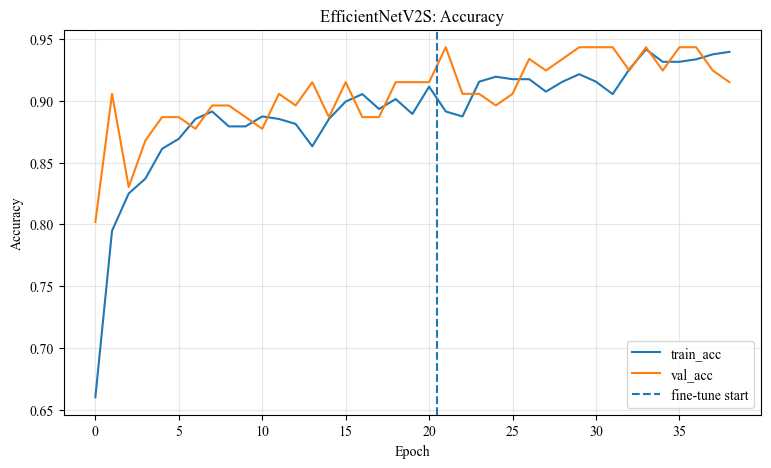

Saved: experiments\efficientnetv2s_20260418_164758\plots\accuracy_curve.png


In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_all["acc"],
    label="train_acc"
)

plt.plot(
    history_all["val_acc"],
    label="val_acc"
)

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("EfficientNetV2S: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "accuracy_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

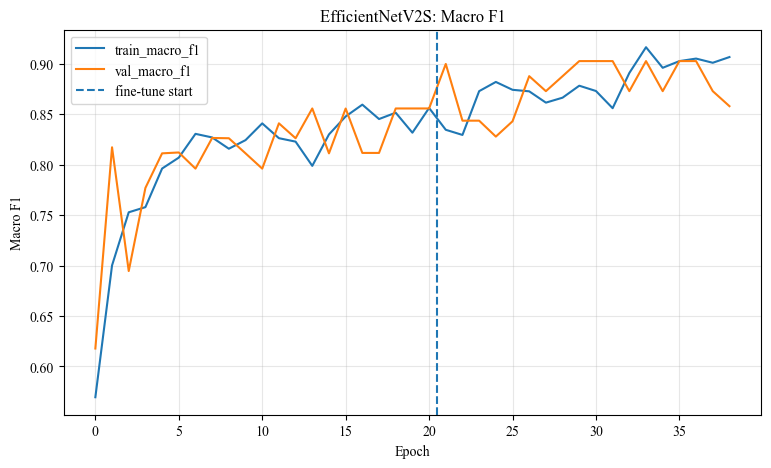

Saved: experiments\efficientnetv2s_20260418_164758\plots\macro_f1_curve.png


In [37]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_all["macro_f1"],
    label="train_macro_f1"
)

plt.plot(
    history_all["val_macro_f1"],
    label="val_macro_f1"
)

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("EfficientNetV2S: Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_f1_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

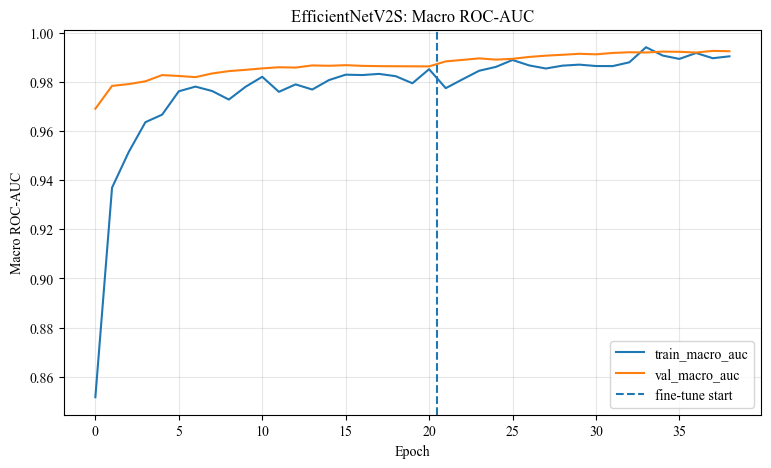

Saved: experiments\efficientnetv2s_20260418_164758\plots\macro_auc_curve.png


In [38]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_all["macro_auc"],
    label="train_macro_auc"
)

plt.plot(
    history_all["val_macro_auc"],
    label="val_macro_auc"
)

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("EfficientNetV2S: Macro ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Macro ROC-AUC")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_auc_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [39]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().tolist())
    y_prob.extend(probs.tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

print("y_true shape:", y_true.shape)
print("y_prob shape:", y_prob.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (106,)
y_prob shape: (106, 4)
y_pred shape: (106,)


In [40]:
report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report_text)

              precision    recall  f1-score   support

          24     1.0000    1.0000    1.0000        23
          48     1.0000    0.9500    0.9744        20
          72     0.9231    1.0000    0.9600        12
     healthy     1.0000    1.0000    1.0000        51

    accuracy                         0.9906       106
   macro avg     0.9808    0.9875    0.9836       106
weighted avg     0.9913    0.9906    0.9906       106



In [46]:
test_results = model.evaluate(test_ds, return_dict=True)

print("Test results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - acc: 0.9896 - loss: 0.1119 - macro_auc: 0.7490 - macro_f1: 0.7710 - top2_acc: 1.0000
Test results:
acc: 0.9906
loss: 0.1090
macro_auc: 0.9990
macro_f1: 0.9836
top2_acc: 1.0000
